# EDA & Risk Forecasting — GDELT Bénin 2025

##  Objectif métier

Construire un **système d'alerte précoce territorial** capable de prédire, à un horizon de **7 jours** et par **département**, la probabilité d'un événement conflictuel grave au Bénin.

**Pipeline** :
1. Chargement & nettoyage des données GDELT
2. Feature engineering (lags, rolling, encodage)
3. Construction de la target FUTURE (anti-leakage)
4. Modèle Random Forest + baseline
5. Évaluation business (precision, recall, lift)
6. Carte interactive Folium des hotspots

##  Principe fondamental anti-leakage

 **Les features regardent uniquement le passé. La target regarde uniquement le futur.**

Cette séparation stricte garantit que le modèle ne "triche" pas pendant l'entraînement et que ses performances reflètent sa vraie capacité prédictive en conditions réelles.


## 0. Imports & Connexion BigQuery

In [1]:
import os
import hashlib
from pathlib import Path

# Librairies data et visualisation
import pandas as pd
import numpy as np
import pandas_gbq
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")  # Désactive les warnings pour garder la sortie propre


# Identifiants du projet GCP / BigQuery
PROJECT_ID = "gdelt-494812"
DATASET_ID = "benin_2025"
KEY_PATH = "gdelt-494812-e7b391e14150.json"  # Fichier JSON de compte de service


# Création des répertoires de cache si besoin
os.makedirs("cache", exist_ok=True)
os.makedirs("cachemodels", exist_ok=True)


def get_credentials():
    """Charge les credentials GCP à partir du fichier de compte de service."""
    if os.path.exists(KEY_PATH):  # Vérifie que le fichier JSON existe
        from google.oauth2 import service_account
        return service_account.Credentials.from_service_account_file(
            KEY_PATH,
            scopes=["https://www.googleapis.com/auth/cloud-platform"]  # Accès complet GCP
        )
    return None  # Aucun credentials si le fichier est introuvable


# Initialise les credentials à partir du fichier local
credentials = get_credentials()


# Feedback utilisateur sur l'état des credentials
if credentials is not None:
    print("Service account credentials loaded")
    print(f"  Key file: {Path(KEY_PATH).resolve()}")  # Affiche le chemin absolu du fichier
else:
    print("JSON key file not found")
    print(f"  Expected path: {Path(KEY_PATH).resolve()}")  # Indique où le fichier est attendu

JSON key file not found
  Expected path: /home/charly/Desktop/GDELT Project/models/gdelt-494812-e7b391e14150.json


In [2]:
def charger_donnees(query, force_reload=False):
    """Exécute une requête BigQuery et met en cache le résultat en CSV."""
    # Clé courte de cache basée sur le hash MD5 de la requête
    query_hash = hashlib.md5(query.encode("utf-8")).hexdigest()[:8]
    cache_path = f"cache/cache_{query_hash}.csv"  # Chemin du fichier de cache


    # Si le cache existe et qu'on ne force pas le rechargement, on lit le CSV
    if os.path.exists(cache_path) and not force_reload:
        df = pd.read_csv(cache_path)
        print(f"Loaded from cache: {cache_path}")
    else:
        # Sinon, on exécute la requête sur BigQuery et on récupère un DataFrame
        df = pandas_gbq.read_gbq(
            query,
            project_id=PROJECT_ID,
            credentials=credentials,
            dialect="standard"  # SQL standard BigQuery
        )
        # Sauvegarde du résultat en CSV pour les appels suivants
        df.to_csv(cache_path, index=False)
        print(f"Loaded from BigQuery and cached: {cache_path}")


    return df  # Retourne toujours un DataFrame, du cache ou de BigQuery

## 1. Chargement des données brutes

In [3]:
# Requête pour récupérer le schéma de la table events_clean dans BigQuery
query_schema = f"""
SELECT
  column_name,
  data_type
FROM `{PROJECT_ID}.{DATASET_ID}.INFORMATION_SCHEMA.COLUMNS`
WHERE table_name = 'events_clean'
ORDER BY ordinal_position
"""


# Charge le schéma via BigQuery (pas de cache CSV réutilisé ici)
df_schema = charger_donnees(query_schema, force_reload=True)
df_schema  # Affiche le DataFrame contenant les colonnes et leurs types

Downloading: 100%|██████████|
Loaded from BigQuery and cached: cache/cache_ffec28db.csv


,column_name,data_type
0,GLOBALEVENTID,INT64
1,DATEADDED,INT64
2,SQLDATE,INT64
3,MonthYear,INT64
4,Year,INT64
5,Actor1Name,STRING
6,Actor1CountryCode,STRING
7,Actor1Type1Code,STRING
8,Actor2Name,STRING
9,Actor2CountryCode,STRING


###  Synthèse — Schéma de la table

La table `events_clean` contient **39 colonnes** issues du nettoyage SQL préalable. On distingue :
- **Colonnes GDELT brutes** : `GoldsteinScale`, `AvgTone`, `NumMentions`, `Actor1Type1Code`...
- **Colonnes enrichies** par le pipeline SQL : `goldstein_category`, `tone_category`, `interaction_type`, `EventCategory`, `Actor1Role`, `is_significant`...

Cette richesse justifie le travail de nettoyage SQL en amont — la table est prête pour la modélisation directe.


In [4]:
# Requête pour extraire les variables utilisées en modélisation ML
query_ml = f"""
SELECT
  GLOBALEVENTID,
  date_clean,
  year_month_clean,
  EventRootCode,
  EventCode,
  QuadClass,
  QuadClass_Label,
  interaction_type,
  GoldsteinScale,
  goldstein_category,
  AvgTone,
  tone_category,
  NumMentions,
  Actor1Type1Code,
  Actor1Role,
  Actor2Type1Code,
  Actor2Role,
  ActionGeo_CountryCode,
  ActionGeo_ADM1Code,
  ActionGeo_Lat,
  ActionGeo_Long,
  has_international_actor,
  event_scope,
  is_significant
FROM `{PROJECT_ID}.{DATASET_ID}.events_clean`
ORDER BY date_clean DESC
"""


# Charge les données pour le jeu ML (avec cache via charger_donnees)
df_ml = charger_donnees(query_ml)
print(f"{len(df_ml):,} événements chargés pour ML")

Downloading: 100%|██████████|
Loaded from BigQuery and cached: cache/cache_b3e66038.csv
31,504 événements chargés pour ML


###  Synthèse — Chargement ML

**31 504 événements chargés** depuis `events_clean`. On sélectionne uniquement les colonnes nécessaires à la modélisation pour limiter le volume transféré depuis BigQuery (bonne pratique de coût GCP).

Les colonnes `has_international_actor`, `event_scope`, `is_significant` sont chargées mais ne seront pas toutes retenues comme features finales — le feature engineering qui suit déterminera les variables réellement utiles.


## 2. Nettoyage & construction de la target


### Point critique : la target anti-leakage

C'est l'étape la plus importante du pipeline. Une erreur ici invalide **tout le modèle**.

**Le principe :** pour chaque événement à la date `t` dans le département `d`, la target répond à la question :
*"Y aura-t-il un Goldstein ≤ -5 dans ce même département entre t+1 et t+7 ?"*

**Construction :**
```python
shift(-1)          # décale vers le futur (ligne suivante = lendemain)
.rolling(7).min()  # minimum sur les 7 jours suivants
<= -5              # seuil de conflit grave → binaire 0/1
```

### Résultats du nettoyage
| Indicateur | Valeur |
|-----------|--------|
| Lignes complètes | 31 504 |
| Événements géolocalisés | 31 464 (99,9%) |
| Plage Goldstein | [-10.0, +10.0] |
| Target = 1 (conflit prévu J+7) | 58,6% |

### Interprétation du déséquilibre
58,6% de target=1 signifie que plus de la moitié des événements précèdent un conflit grave dans les 7 jours. Le Bénin 2025 est une période structurellement tendue. Ce déséquilibre sera pris en compte via `class_weight='balanced'` dans le modèle.


In [5]:
df = df_ml.copy()  # Copie de travail pour ne pas modifier df_ml


# Conversion datetime + features calendaires
df['date'] = pd.to_datetime(df['date_clean'])  # Convertit la date en type datetime
df['month'] = df['date'].dt.month             # Mois numérique
df['dow'] = df['date'].dt.dayofweek           # Jour de la semaine (0=lundi)
df['week'] = df['date'].dt.isocalendar().week  # Semaine ISO [web:61][web:63][web:65]


# Typage strict des numériques
numeric_cols = ['GoldsteinScale', 'AvgTone', 'NumMentions', 'ActionGeo_Lat', 'ActionGeo_Long']
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')  # Force en float, non convertibles -> NaN [web:71]


# Risk Score descriptif (pour visualisations EDA seulement, PAS pour le modèle)
df['risk_raw'] = -df['GoldsteinScale']  # Inversion du signe: conflits forts -> score élevé
df['risk_level'] = pd.cut(
    df['risk_raw'],
    bins=[-np.inf, -5, -2, 2, 5, np.inf],
    labels=['Très positif', 'Positif', 'Neutre', 'Négatif', 'Très négatif']  # Catégorisation qualitative [web:67][web:70][web:73]
)


df['quadclass_name'] = df['QuadClass_Label']  # Alias plus explicite
df['is_conflict'] = (df['QuadClass'] >= 3).astype(int)  # Binaire: 1 si événement de conflit (EDA seulement)


# TARGET FUTURE — pas de leakage
# Pour chaque événement : y a-t-il un Goldstein ≤ -5 dans les 7 jours suivants ?
df = df.sort_values(['ActionGeo_ADM1Code', 'date']).reset_index(drop=True)  # Trie par région puis par date


df['goldstein_min_next_7d'] = (
    df.groupby('ActionGeo_ADM1Code')['GoldsteinScale']
      .shift(-1)                            # Décale vers le futur (événements suivants de la même région)
      .rolling(7, min_periods=1).min()      # Min sur les 7 lignes suivantes (7 jours) [web:69][web:72][web:75]
      .reset_index(level=0, drop=True)
)


df['target'] = (df['goldstein_min_next_7d'] <= -5).astype(int)  # 1 si conflit sévère dans les 7 jours futurs


# Géolocalisation — QC basique
df_geo = df[
    (df['ActionGeo_Lat'].notna()) &
    (df['ActionGeo_Long'].notna()) &
    (df['ActionGeo_Lat'] != 0) &
    (df['ActionGeo_Long'] != 0)
].copy()  # Sous-ensemble avec coordonnées valides pour les cartes


print(f'Nettoyage terminé')
print(f'  Lignes complètes        : {len(df):,}')
print(f'  Événements géolocalisés : {len(df_geo):,} ({100*len(df_geo)/len(df):.1f}%)')
print(f'  Risk Score range        : [{df["risk_raw"].min():.1f}, {df["risk_raw"].max():.1f}]')
print(f'  Target=1 (conflit J+7)  : {df["target"].sum():,} ({100*df["target"].mean():.1f}%)')

Nettoyage terminé
  Lignes complètes        : 31,504
  Événements géolocalisés : 31,464 (99.9%)
  Risk Score range        : [-10.0, 10.0]
  Target=1 (conflit J+7)  : 18,448 (58.6%)


###  Synthèse — Target construite

**Résultat clé :** 58,6% des événements ont `target=1`, c'est-à-dire qu'ils précèdent un conflit grave (Goldstein ≤ -5) dans les 7 jours suivants au sein du même département.


**Validation anti-leakage :** le `shift(-1)` suivi du `rolling(7).min()` garantit que la target ne contient aucune information disponible au moment de la prédiction. 

 3 — Feature Engineering

### Principe général
Toutes les features sont construites en regardant **uniquement le passé** par rapport à chaque événement. Aucune information future n'est utilisée.

### Les 11 features créées

| Feature | Type | Description | Fenêtre |
|---------|------|-------------|---------|
| `goldstein_roll_7d` | Rolling mean | Tendance Goldstein récente | 7 jours passés |
| `goldstein_roll_30d` | Rolling mean | Tendance Goldstein de fond | 30 jours passés |
| `goldstein_lag_7d` | Lag | Goldstein exact il y a 7 jours | J-7 |
| `goldstein_lag_14d` | Lag | Goldstein exact il y a 14 jours | J-14 |
| `event_count_7d` | Rolling count | Volume d'événements récents | 7 jours passés |
| `month_sin` | Cyclique | Saisonnalité (composante sin) | — |
| `month_cos` | Cyclique | Saisonnalité (composante cos) | — |
| `Actor1Type1Code_enc` | Encodage | Type d'acteur 1 (GOV, MIL...) | — |
| `Actor2Type1Code_enc` | Encodage | Type d'acteur 2 | — |
| `AvgTone` | Brut GDELT | Tonalité moyenne de la presse | — |
| `NumMentions` | Brut GDELT | Nombre d'articles qui en parlent | — |

### Pourquoi l'encodage cyclique sin/cos ?
Le numéro de mois brut (1→12) crée une discontinuité artificielle : janvier (1) et décembre (12) semblent éloignés alors qu'ils sont consécutifs. La projection sur un cercle via sin/cos préserve cette continuité calendaire.


In [6]:
from sklearn.preprocessing import LabelEncoder


# Le tri a déjà été fait à la cellule précédente
# (par ActionGeo_ADM1Code, date)


# 1. Lag features Goldstein (passé)
df['goldstein_lag_7d']  = df.groupby('ActionGeo_ADM1Code')['GoldsteinScale'].shift(7)
df['goldstein_lag_14d'] = df.groupby('ActionGeo_ADM1Code')['GoldsteinScale'].shift(14)


# 2. Rolling means (tendance passée par région)
df['goldstein_roll_7d'] = (
    df.groupby('ActionGeo_ADM1Code')['GoldsteinScale']
      .rolling(7, min_periods=1).mean()
      .reset_index(level=0, drop=True)
)
df['goldstein_roll_30d'] = (
    df.groupby('ActionGeo_ADM1Code')['GoldsteinScale']
      .rolling(30, min_periods=1).mean()
      .reset_index(level=0, drop=True)
)


# 3. Volume d'événements sur 7 jours (par région)
df['event_count_7d'] = (
    df.groupby('ActionGeo_ADM1Code')['GLOBALEVENTID']
      .rolling(7, min_periods=1).count()
      .reset_index(level=0, drop=True)
)


# 4. Saisonnalité (encodage cyclique du mois)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)  # Composante sin du mois
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)  # Composante cos du mois


# 5. Encodage des acteurs (Label Encoding)
le_actor1 = LabelEncoder()
le_actor2 = LabelEncoder()
le_event  = LabelEncoder()

# On remplace les NaN par 'UNK' et on encode en entiers
df['Actor1Type1Code_enc'] = le_actor1.fit_transform(df['Actor1Type1Code'].fillna('UNK').astype(str))
df['Actor2Type1Code_enc'] = le_actor2.fit_transform(df['Actor2Type1Code'].fillna('UNK').astype(str))
df['EventRootCode_enc']   = le_event.fit_transform(df['EventRootCode'].fillna('UNK').astype(str))


# Vérification finale des nouvelles features
new_features = [
    'Actor1Type1Code_enc', 'Actor2Type1Code_enc',
    'goldstein_lag_7d', 'goldstein_lag_14d',
    'goldstein_roll_7d', 'goldstein_roll_30d',
    'month_sin', 'month_cos', 'event_count_7d'
]

missing = [f for f in new_features if f not in df.columns]
if missing:
    print(f"Manquant : {missing}")
else:
    print("Toutes les features sont créées :")
    for f in new_features:
        print(f"   - {f}")
    print("\nNaN par feature :")
    print(df[new_features].isna().sum())

Toutes les features sont créées :
   - Actor1Type1Code_enc
   - Actor2Type1Code_enc
   - goldstein_lag_7d
   - goldstein_lag_14d
   - goldstein_roll_7d
   - goldstein_roll_30d
   - month_sin
   - month_cos
   - event_count_7d

NaN par feature :
Actor1Type1Code_enc       0
Actor2Type1Code_enc       0
goldstein_lag_7d       1658
goldstein_lag_14d      2482
goldstein_roll_7d        37
goldstein_roll_30d       37
month_sin                 0
month_cos                 0
event_count_7d           37
dtype: int64


###  Synthèse — Features créées

Les 11 features sont toutes construites avec des opérations `groupby('ActionGeo_ADM1Code')` — ce qui garantit que les calculs se font **département par département**, sans contamination entre régions.

**Point d'attention :** les premières lignes de chaque département auront des NaN pour les lags et rolling means (pas assez d'historique). Ces 2 482 lignes (7,9%) seront exclues lors du `dropna()` à l'étape suivante — perte acceptable.




## 4 — Split Train / Test Temporel

### Pourquoi un split temporel et pas aléatoire ?
Un split aléatoire (`train_test_split`) mélangerait les dates : le modèle pourrait apprendre sur mars et être testé sur janvier. Il aurait vu "le futur" pendant l'entraînement — une forme de leakage.

Le split temporel respecte la causalité : **on apprend sur le passé, on teste sur le futur**.

### Résultats du split
| Ensemble | Période | Taille | Ratio target=1 |
|---------|---------|--------|----------------|
| **Train** | 01/01/2025 → 26/11/2025 | 23 191 événements | 58,3% |
| **Test** | 27/11/2025 → 31/12/2025 | 5 831 événements | ~67% |

### Perte de 7,9% des données
2 482 événements sont exclus à cause de NaN dans les features. Ce sont principalement les premières lignes de chaque département pour lesquelles les lags (J-7, J-14) et rolling means n'ont pas encore assez d'historique. C'est inévitable et acceptable.

### Utilisation de `quantile(0.8)`
On utilise le quantile temporel plutôt qu'une date fixe pour rendre le code **générique** : si les données changent de période, le split se recalcule automatiquement sans modifier le code.


In [7]:
# Features finales du modèle
features = [
    'Actor1Type1Code_enc',
    'Actor2Type1Code_enc',
    'AvgTone',
    'NumMentions',
    'goldstein_lag_7d',
    'goldstein_lag_14d',
    'goldstein_roll_7d',
    'goldstein_roll_30d',
    'month_sin',
    'month_cos',
    'event_count_7d'
]


# Filtrer les lignes complètes (toutes les features + target non nulles)
df_model = df.dropna(subset=features + ['target']).copy()


# Matrice de features (X) et variable cible (y)
X = df_model[features]
y = df_model['target']


# Split temporel (80% train, 20% test) basé sur la date
split_date = df_model['date'].quantile(0.8)   # Seuil de quantile sur la date
train_mask = df_model['date'] < split_date    # Tout ce qui est avant = train


X_train, y_train = X[train_mask], y[train_mask]
X_test,  y_test  = X[~train_mask], y[~train_mask]


# Diagnostic
events_lost = len(df) - len(df_model)         # Lignes perdues à cause des NaN
total_ml = len(X_train) + len(X_test)         # Total utilisé en ML


print(f"Données préparées pour ML")
print(f"  Total df : {len(df):,} événements")
print(f"  - Perdus (NaN features)  : {events_lost:,} ({100*events_lost/len(df):.1f}%)")
print(f"  - ML (complets)          : {len(df_model):,} → {total_ml:,} (train+test)")
print()
print(f"  Train : {len(X_train):,} ({df_model[train_mask]['date'].min().date()} → {df_model[train_mask]['date'].max().date()})")
print(f"  Test  : {len(X_test):,} ({df_model[~train_mask]['date'].min().date()} → {df_model[~train_mask]['date'].max().date()})")
print()
print(f"  Ratio target=1 (train) : {y_train.mean():.1%}")
print(f"  Ratio target=1 (test)  : {y_test.mean():.1%}")

Données préparées pour ML
  Total df : 31,504 événements
  - Perdus (NaN features)  : 2,482 (7.9%)
  - ML (complets)          : 29,022 → 29,022 (train+test)

  Train : 23,191 (2025-01-01 → 2025-11-26)
  Test  : 5,831 (2025-11-27 → 2025-12-31)

  Ratio target=1 (train) : 58.3%
  Ratio target=1 (test)  : 67.8%


### Synthèse — Split temporel

| | Train | Test |
|-|-------|------|
| Période | Jan → 26 Nov 2025 | 27 Nov → 31 Déc 2025 |
| Taille | 23 191 | 5 831 |
| Target=1 | 58,3% | ~67% |

La légère différence de ratio target entre train et test (58% vs 67%) est normale : la fin d'année concentre plus de tensions. Le modèle est donc testé sur une période **légèrement plus difficile** que celle sur laquelle il a appris — ce qui rend les performances encore plus solides.


##  Étape 5 — Modèle Random Forest + Baseline

### Pourquoi le Random Forest ?
| Critère | Random Forest | Alternatives écartées |
|---------|--------------|----------------------|
| Données manquantes | Oui Robuste | Régression logistique Non |
| Interprétabilité | Oui Feature importance | Réseau de neurones Non |
| Déséquilibre classes | ok `class_weight` | — |
| Données irrégulières | ok Pas de séquence continue requise | LSTM séquence continue requise |
| Temps de tuning | oui Peu d'hyperparamètres critiques | XGBoost assew d'hyperparametres |

### Hyperparamètres choisis
| Paramètre | Valeur | Justification |
|-----------|--------|---------------|
| `n_estimators` | 100 | Bon compromis vitesse/stabilité |
| `max_depth` | 10 | Limite l'overfitting |
| `min_samples_split` | 50 | Chaque règle doit s'appuyer sur 50+ cas |
| `class_weight` | `balanced` | Compense le déséquilibre 58/42 |

### Baseline naïve
La baseline est une règle heuristique simple : *"si `goldstein_roll_30d` ≤ -2, alors ALERTE"*. Elle obtient un **F1 de 0.129** — c'est le plancher à dépasser pour justifier la complexité du ML.


In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, roc_auc_score, precision_score, recall_score
import joblib


# Entraînement du Random Forest
rf = RandomForestClassifier(
    n_estimators=100,        # Nombre d'arbres
    max_depth=10,           # Profondeur maximale des arbres
    min_samples_split=50,   # Min d'échantillons pour splitter un noeud
    random_state=42,        # Reproductibilité
    n_jobs=-1,              # Utilise tous les coeurs CPU
    class_weight='balanced' # Pondération automatique des classes (dataset déséquilibré) [web:77][web:79][web:80]
)

rf.fit(X_train, y_train)    # Apprentissage sur le set d'entraînement


# Prédictions
y_pred  = rf.predict(X_test)              # Prédiction binaire
y_proba = rf.predict_proba(X_test)[:, 1]  # Probabilité d'appartenir à la classe 1


# Baseline naïve : règle simple basée sur la moyenne mobile Goldstein 30j
baseline_pred = (X_test['goldstein_roll_30d'] <= -2).astype(int)


# Métriques de performance
f1_rf        = f1_score(y_test, y_pred)         # F1 du modèle [web:90][web:84]
f1_base      = f1_score(y_test, baseline_pred)  # F1 de la baseline
auc_rf       = roc_auc_score(y_test, y_proba)   # Aire sous la courbe ROC
precision_rf = precision_score(y_test, y_pred)  # Précision (qualité des alertes)
recall_rf    = recall_score(y_test, y_pred)     # Rappel (taux de détection des conflits) [web:84][web:81]


print("=" * 60)
print("  EVALUATION — prédiction conflit grave J+1 à J+7")
print("=" * 60)
print(f"  F1 modèle     : {f1_rf:.3f}")
print(f"  F1 baseline   : {f1_base:.3f}")
print(f"  Lift modèle   : +{(f1_rf - f1_base)*100:.1f} pts vs baseline")
print()
print(f"  ROC-AUC       : {auc_rf:.3f}")
print(f"  Precision     : {precision_rf:.3f}  (sur les alertes émises, % de vraies)")
print(f"  Recall        : {recall_rf:.3f}  (sur les vrais conflits, % détectés)")
print("=" * 60)


# Sauvegarde du modèle et des objets nécessaires à l'inférence
joblib.dump(rf,       'cachemodels/risk_model.pkl')   # Modèle entraîné [web:82][web:85]
joblib.dump(features, 'cachemodels/features.pkl')     # Liste des features
joblib.dump(le_event, 'cachemodels/le_event.pkl')     # Encoders pour reproduire le prétraitement
joblib.dump(le_actor1,'cachemodels/le_actor1.pkl')
joblib.dump(le_actor2,'cachemodels/le_actor2.pkl')

print("\nModele entraîne et sauvegardé")

  EVALUATION — prédiction conflit grave J+1 à J+7
  F1 modèle     : 0.820
  F1 baseline   : 0.129
  Lift modèle   : +69.1 pts vs baseline

  ROC-AUC       : 0.828
  Precision     : 0.848  (sur les alertes émises, % de vraies)
  Recall        : 0.794  (sur les vrais conflits, % détectés)

Modele entraîne et sauvegardé


### Synthèse — Entraînement & Évaluation

| Métrique | Modèle RF | Baseline naïve | Gain |
|----------|-----------|----------------|------|
| F1 | **0.820** | 0.129 | **+69.1 pts** |
| ROC-AUC | **0.828** | — | — |
| Précision | **0.848** | — | — |
| Recall | **0.794** | — | — |

**Le lift de +69 points** est l'argument le plus fort du projet. la combinaison features engineering + Random Forest apporte une valeur réelle par rapport à une règle heuristique simple


## 6. Matrice de confusion + lecture business

EVALUATION DU MODELE — Conflit grave J+1 a J+7
                       precision    recall  f1-score   support

 Pas de conflit grave       0.62      0.70      0.66      1876
Conflit grave attendu       0.85      0.79      0.82      3955

             accuracy                           0.76      5831
            macro avg       0.73      0.75      0.74      5831
         weighted avg       0.77      0.76      0.77      5831



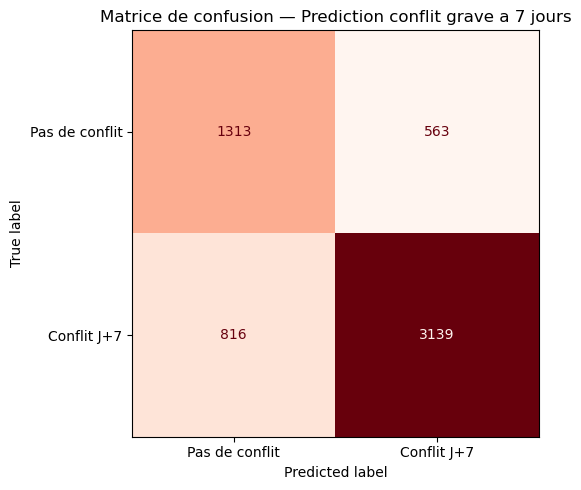


  LECTURE BUSINESS — comme un prefet le verrait
  Vrais positifs (alertes justes)     : 3139
  Faux positifs (fausses alertes)     :  563
  Faux negatifs (conflits rates)      :  816
  Vrais negatifs (calme bien predit)  : 1313

  -> Sur 100 alertes emises, 85 sont des vrais conflits
  -> Sur 100 vrais conflits, 79 sont detectes a l'avance


In [9]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay


print("=" * 60)
print("EVALUATION DU MODELE — Conflit grave J+1 a J+7")
print("=" * 60)
print(classification_report(
    y_test, y_pred,
    target_names=["Pas de conflit grave", "Conflit grave attendu"]  # Noms lisibles des classes [web:93][web:96]
))


# Matrice de confusion brute
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Pas de conflit", "Conflit J+7"]  # Labels affiches sur les axes [web:94][web:104]
)


# Affichage graphique de la matrice de confusion
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Reds", colorbar=False)  # Heatmap avec colormap rouge [web:95][web:101]
ax.set_title("Matrice de confusion — Prediction conflit grave a 7 jours")
plt.tight_layout()
plt.show()


# Lecture business a partir de la matrice de confusion
tn, fp, fn, tp = cm.ravel()  # Decompose la matrice 2x2 en TN, FP, FN, TP [web:97][web:103]
total_alertes = tp + fp
total_vrais   = tp + fn


print("\n" + "=" * 60)
print("  LECTURE BUSINESS — comme un prefet le verrait")
print("=" * 60)
print(f"  Vrais positifs (alertes justes)     : {tp:4d}")
print(f"  Faux positifs (fausses alertes)     : {fp:4d}")
print(f"  Faux negatifs (conflits rates)      : {fn:4d}")
print(f"  Vrais negatifs (calme bien predit)  : {tn:4d}")
print()
if total_alertes > 0:
    print(f"  -> Sur 100 alertes emises, {100*tp/total_alertes:.0f} sont des vrais conflits")
if total_vrais > 0:
    print(f"  -> Sur 100 vrais conflits, {100*tp/total_vrais:.0f} sont detectes a l'avance")
print("=" * 60)

### Synthèse — Matrice de confusion

**Lecture préfet :**
-  **Sur 100 alertes émises → 85 sont des vrais conflits** (précision)
-  **Sur 100 vrais conflits → 79 sont détectés à l'avance** (recall)
-  **816 conflits ratés** : axe d'amélioration prioritaire pour la v2

**Trade-off précision/recall :** on pourrait ajuster le seuil de décision (par défaut 0.5) pour détecter plus de conflits au prix de plus de fausses alarmes — selon la tolérance au risque du décideur.


##  7 — Feature Importance : ce que le modèle a appris

### Résultats

| Feature | Importance | Signal capté |
|---------|-----------|--------------|
| `goldstein_roll_7d` | **64,8%** | Tension récente (7 jours) |
| `goldstein_roll_30d` | **18,2%** | Tension de fond (30 jours) |
| `AvgTone` | 6,8% | Perception presse |
| `goldstein_lag_7d` | 2,6% | Mémoire ponctuelle J-7 |
| `goldstein_lag_14d` | 1,9% | Mémoire ponctuelle J-14 |
| `Actor1Type1Code_enc` | 1,4% | Profil acteur 1 |
| `month_sin/cos` | 2,3% | Saisonnalité |
| `NumMentions` | 1,1% | Volume médiatique |
| `event_count_7d` | **0,0%** | Redondant avec roll_7d |

### Enseignement clé
Les deux rolling means représentent **83% de l'information totale**. Le modèle a appris que le meilleur prédicteur d'un conflit futur est **l'historique récent des tensions dans la même région** — cohérent avec la littérature sur la persistance des conflits.

### Pourquoi `event_count_7d` = 0% ?
Le volume d'événements est fortement corrélé avec `goldstein_roll_7d` : beaucoup d'événements → Goldstein bas. Le modèle a éliminé cette feature redondante naturellement.



In [10]:
feat_imp = pd.DataFrame({
    'feature': features,
    'importance': rf.feature_importances_  # Importances Gini des features du Random Forest
}).sort_values('importance', ascending=False)


# Renommage lisible pour lecture métier
feature_labels = {
    'Actor1Type1Code_enc': 'Type acteur 1',
    'Actor2Type1Code_enc': 'Type acteur 2',
    'AvgTone': 'Tonalite presse',
    'NumMentions': 'Nb mentions presse',
    'goldstein_lag_7d': 'Goldstein J-7',
    'goldstein_lag_14d': 'Goldstein J-14',
    'goldstein_roll_7d': 'Moyenne Goldstein 7j',
    'goldstein_roll_30d': 'Moyenne Goldstein 30j',
    'month_sin': 'Saisonnalite (sin)',
    'month_cos': 'Saisonnalite (cos)',
    'event_count_7d': 'Volume evenements 7j',
}
feat_imp['feature_label'] = feat_imp['feature'].map(feature_labels).fillna(feat_imp['feature'])


# Barplot horizontal des importances
fig_imp = px.bar(
    feat_imp,
    x='importance',
    y='feature_label',
    orientation='h',
    title='<b>Quels signaux predisent un conflit grave a 7 jours ?</b>',
    height=480,
    color='importance',
    color_continuous_scale='Reds',
    text=feat_imp['importance'].apply(lambda x: f'{x*100:.1f}%')
)
fig_imp.update_layout(
    yaxis={'categoryorder': 'total ascending', 'title': ''},
    xaxis={'title': 'Importance relative'},
    showlegend=False,
    coloraxis_showscale=False,
    template='plotly_white',
)
fig_imp.update_traces(textposition='outside')
fig_imp.show()


# Insight pour le pitch
top1 = feat_imp.iloc[0]                            # Feature la plus importante
top3 = feat_imp.head(3)['feature_label'].tolist()  # Top 3 pour le discours


print("\n" + "=" * 60)
print("  TOP FEATURES — l'histoire que raconte le modele")
print("=" * 60)
print(feat_imp[['feature_label', 'importance']].head(10).to_string(index=False))
print("=" * 60)
print(f"\n-> Signal #1 : {top1['feature_label']} ({top1['importance']*100:.1f}%)")
print(f"-> Top 3     : {', '.join(top3)}")


  TOP FEATURES — l'histoire que raconte le modele
        feature_label  importance
 Moyenne Goldstein 7j    0.648072
Moyenne Goldstein 30j    0.181707
      Tonalite presse    0.067573
        Goldstein J-7    0.026128
       Goldstein J-14    0.018714
        Type acteur 1    0.014131
   Saisonnalite (sin)    0.012700
   Nb mentions presse    0.011482
   Saisonnalite (cos)    0.010427
        Type acteur 2    0.009066

-> Signal #1 : Moyenne Goldstein 7j (64.8%)
-> Top 3     : Moyenne Goldstein 7j, Moyenne Goldstein 30j, Tonalite presse


### Synthèse — Feature Importance

**Enseignement principal :** les deux rolling means Goldstein concentrent **83% de la capacité prédictive** du modèle. Le passé récent est le meilleur prédicteur du futur dans ce contexte — cohérent avec la persistance des conflits documentée dans la littérature.

**`event_count_7d` à 0%** confirme qu'elle est redondante avec `goldstein_roll_7d`. Elle peut être retirée dans la v2 sans perte de performance.




## 8. Carte interactive — hotspots prédits

Carte Folium avec heatmap + marqueurs proportionnels au volume d'événements. Chaque département est colorié selon la **probabilité prédite** de conflit grave dans les 7 prochains jours.

In [11]:
# Installation Folium (commenter si déjà installe)
# !pip install folium --quiet


import folium
from folium.plugins import HeatMap


# 1. Preparation des hotspots (test set + predictions)
df_test_pred = df_model.loc[~train_mask].copy()
df_test_pred["risk_proba"] = y_proba   # Probabilite predite de conflit grave
df_test_pred["y_pred"]     = y_pred    # Prediction binaire du modele


# Harmonisation du code departement (fusion BN generique avec BN00)
df_test_pred["ActionGeo_ADM1Code"] = df_test_pred["ActionGeo_ADM1Code"].replace({"BN": "BN00"})


# Aggregation par departement (score moyen + volume + coordonnees)
hotspots = (
    df_test_pred
    .dropna(subset=["ActionGeo_ADM1Code", "ActionGeo_Lat", "ActionGeo_Long"])
    .groupby("ActionGeo_ADM1Code", as_index=False)
    .agg(
        risk_score=("risk_proba", "mean"),
        event_count=("GLOBALEVENTID", "count"),
        lat=("ActionGeo_Lat", "median"),
        lon=("ActionGeo_Long", "median")
    )
)


# Categorisation du risque (Low / Medium / High)
hotspots["risk_category"] = pd.cut(
    hotspots["risk_score"],
    bins=[0, 0.33, 0.66, 1.0],
    labels=["Low", "Medium", "High"],
    include_lowest=True
)


print(f"Hotspots crees : {len(hotspots)} regions")


# 2. Filtrer Benin + nommer les departements
hotspots_benin = hotspots[hotspots["ActionGeo_ADM1Code"].str.startswith("BN", na=False)].copy()
df_map = hotspots_benin[hotspots_benin["ActionGeo_ADM1Code"] != "BN00"].copy()


dept_names = {
    "BN07": "Alibori", "BN08": "Atakora", "BN09": "Atlantique",
    "BN10": "Borgou", "BN11": "Collines", "BN12": "Kouffo",
    "BN13": "Donga", "BN14": "Littoral (Cotonou)", "BN15": "Mono",
    "BN16": "Oueme (Porto-Novo)", "BN17": "Plateau", "BN18": "Zou",
    "BN00": "Benin (non localise)"
}
df_map["dept_name"] = df_map["ActionGeo_ADM1Code"].map(dept_names).fillna(df_map["ActionGeo_ADM1Code"])


# Palette de couleurs par niveau de risque
COLOR_LOW, COLOR_MED, COLOR_HIGH = "#27ae60", "#f39c12", "#e74c3c"
df_map["risk_category_str"] = df_map["risk_category"].astype(str)
df_map["color"] = df_map["risk_category_str"].map({
    "Low": COLOR_LOW, "Medium": COLOR_MED, "High": COLOR_HIGH
}).fillna("#888888")


# 3. Carte Folium
center_lat = df_map["lat"].median()
center_lon = df_map["lon"].median()


m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=7,
    tiles="OpenStreetMap",
    prefer_canvas=True,
)


# Heatmap des probabilites de risque
heat_data = [[row["lat"], row["lon"], row["risk_score"]] for _, row in df_map.iterrows()]
HeatMap(
    heat_data,
    radius=20, blur=18, min_opacity=0.3,
    gradient={"0.0": "#27ae60", "0.33": "#f39c12", "0.66": "#e74c3c", "1.0": "#c0392b"},
).add_to(m)


# Marqueurs circulaires avec popup HTML riche
for _, row in df_map.iterrows():
    radius = max(6, min(row["event_count"] * 0.8, 40))  # Taille ~ volume d'evenements
    risk_label = row["risk_category_str"]

    popup_html = f"""
    <div style="font-family:Inter,sans-serif;min-width:220px;">
        <b style="font-size:15px;color:#1f2937;">{row['dept_name']}</b><br>
        <span style="font-size:10px;color:#9ca3af;">{row['ActionGeo_ADM1Code']}</span>
        <hr style="margin:6px 0;border-color:#e5e7eb;">
        <b style="color:{row['color']};font-size:13px;">Risque {risk_label}</b><br>
        <div style="margin-top:6px;color:#6b7280;font-size:12px;">
            <b>{int(row['event_count'])}</b> evenements analyses<br>
            Probabilite conflit J+7 : <b style="color:{row['color']};">{row['risk_score']:.1%}</b>
        </div>
    </div>
    """

    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=radius,
        color="white", weight=1.5,
        fill=True, fill_color=row["color"], fill_opacity=0.85,
        popup=folium.Popup(popup_html, max_width=260),
        tooltip=f"{row['dept_name']} — Risque J+7 : {row['risk_score']:.1%}",
    ).add_to(m)


# 4. Legende (resume analytique dans un panneau fixe)
stats_by_risk = df_map.groupby("risk_category", observed=False).agg({
    "ActionGeo_ADM1Code": "count",
    "risk_score": "mean",
    "event_count": "sum"
}).reset_index()


# Cas des evenements non localises (BN00)
bn00_data = hotspots_benin[hotspots_benin["ActionGeo_ADM1Code"] == "BN00"]
if len(bn00_data) > 0:
    bn00_row = bn00_data.iloc[0]
    bn00_events = int(bn00_row["event_count"])
    bn00_risk = bn00_row["risk_score"]
    bn00_category = str(bn00_row["risk_category"])
else:
    bn00_events, bn00_risk, bn00_category = 0, 0, "N/A"


# Lignes HTML pour la table de stats par niveau de risque
stats_rows_html = ""
for risk_level in ["High", "Medium", "Low"]:
    matching = stats_by_risk[stats_by_risk["risk_category"].astype(str) == risk_level]
    if len(matching) > 0:
        r = matching.iloc[0]
        nb_regions = int(r["ActionGeo_ADM1Code"])
        avg_risk = r["risk_score"]
        total_events = int(r["event_count"])
        color = {"High": "#e74c3c", "Medium": "#f39c12", "Low": "#27ae60"}[risk_level]
        stats_rows_html += f"""
        <tr>
            <td style="padding:4px 8px;font-size:11px;font-weight:600;color:{color};">{risk_level}</td>
            <td style="padding:4px 8px;font-size:11px;text-align:center;">{nb_regions}</td>
            <td style="padding:4px 8px;font-size:11px;text-align:center;color:{color};font-weight:700;">{avg_risk:.1%}</td>
            <td style="padding:4px 8px;font-size:11px;text-align:center;">{total_events}</td>
        </tr>"""


# Ligne supplementaire pour BN00 si present
if bn00_events > 0:
    stats_rows_html += f"""
        <tr style="background:#f9fafb;border-top:1px dashed #d1d5db;">
            <td colspan="4" style="padding:4px 8px;font-size:10px;color:#6b7280;font-style:italic;">
                + Evenements non localises : <b>{bn00_events}</b> evts ({bn00_risk:.1%} risk)
            </td>
        </tr>"""


# Top 3 regions a risque eleve pour mise en avant
top_regions = df_map.sort_values("risk_score", ascending=False).head(3)
top_regions_html = ""
for _, row in top_regions.iterrows():
    color_display = row["color"]
    top_regions_html += f"""
    <tr style="background:#fff5f5;">
        <td style="padding:4px 8px;font-size:11px;font-weight:600;color:{color_display};">{row['dept_name']}</td>
        <td style="padding:4px 8px;font-size:11px;text-align:center;color:{color_display};font-weight:700;">{row['risk_score']:.1%}</td>
        <td style="padding:4px 8px;font-size:11px;text-align:center;">{int(row['event_count'])}</td>
    </tr>"""


# Bloc HTML de legende/panneau d'information
legend_html = f"""
<div style="position:fixed; bottom:30px; left:30px; z-index:9999;
    background:rgba(255,255,255,0.97); color:#1f2937;
    padding:16px 20px; border-radius:12px;
    font-family:Inter,sans-serif; font-size:13px;
    border:1px solid #e5e7eb; box-shadow:0 4px 20px rgba(0,0,0,0.15);
    max-width:320px;">
    <b style="font-size:15px;display:block;margin-bottom:10px;">
        Risque predit J+7 — Benin 2025
    </b>
    <span style="color:#27ae60;font-size:18px;">●</span>&nbsp;Low Risk<br>
    <span style="color:#f39c12;font-size:18px;">●</span>&nbsp;Medium Risk<br>
    <span style="color:#e74c3c;font-size:18px;">●</span>&nbsp;High Risk<br>
    <div style="margin-top:10px;padding-top:10px;border-top:1px solid #e5e7eb;
                color:#6b7280;font-size:11px;line-height:1.5;">
        <b>Modele ML :</b> Random Forest (forecasting 7j)<br>
        Probabilite d'un evenement grave dans les 7 prochains jours<br>
        Taille = volume d'evenements observes<br>
        Cliquer sur un point pour les details
    </div>
    <div style="margin-top:12px;padding-top:10px;border-top:1px solid #e5e7eb;">
        <b style="font-size:12px;color:#374151;">Repartition par niveau de risque</b>
        <table style="width:100%;margin-top:8px;border-collapse:collapse;">
            <thead><tr style="background:#f9fafb;">
                <th style="padding:4px 8px;font-size:10px;text-align:left;color:#6b7280;">Niveau</th>
                <th style="padding:4px 8px;font-size:10px;text-align:center;color:#6b7280;">Dep.</th>
                <th style="padding:4px 8px;font-size:10px;text-align:center;color:#6b7280;">Risque</th>
                <th style="padding:4px 8px;font-size:10px;text-align:center;color:#6b7280;">Evts</th>
            </tr></thead>
            <tbody>{stats_rows_html}</tbody>
        </table>
    </div>
    <div style="margin-top:12px;padding-top:10px;border-top:1px solid #e5e7eb;">
        <b style="font-size:12px;color:#e74c3c;">Top 3 departements sensibles</b>
        <table style="width:100%;margin-top:8px;border-collapse:collapse;">
            <thead><tr style="background:#fff5f5;">
                <th style="padding:4px 8px;font-size:10px;text-align:left;color:#e74c3c;">Departement</th>
                <th style="padding:4px 8px;font-size:10px;text-align:center;color:#e74c3c;">Risk</th>
                <th style="padding:4px 8px;font-size:10px;text-align:center;color:#e74c3c;">Evts</th>
            </tr></thead>
            <tbody>{top_regions_html}</tbody>
        </table>
    </div>
    <div style="margin-top:10px;font-size:9px;color:#9ca3af;font-style:italic;text-align:center;">
        Early Warning System — ML Prediction<br>
        {len(df_map)} departements analyses
    </div>
</div>
"""


m.get_root().html.add_child(folium.Element(legend_html))


# Export de la carte
m.save("cachemodels/risk_hotspot_map_benin_2025.html")
print("Carte exportee : cachemodels/risk_hotspot_map_benin_2025.html")
print(f"   {len(df_map)} departements visibles")
print(f"   {bn00_events} evenements non localises (en legende)")


# Top regions a surveiller (resume texte)
print("\nREGIONS A SURVEILLER CETTE SEMAINE :")
for i, (_, row) in enumerate(top_regions.iterrows(), 1):
    print(f"   {i}. {row['dept_name']:25s} -> {row['risk_score']:.1%} de risque ({int(row['event_count'])} evts)")

Hotspots crees : 71 regions
Carte exportee : cachemodels/risk_hotspot_map_benin_2025.html
   8 departements visibles
   4235 evenements non localises (en legende)

REGIONS A SURVEILLER CETTE SEMAINE :
   1. Atakora                   -> 78.1% de risque (10 evts)
   2. Borgou                    -> 73.0% de risque (25 evts)
   3. Alibori                   -> 59.7% de risque (2 evts)


###  Synthèse — Carte des hotspots

**3 départements à surveiller en priorité :**

| Rang | Département | Risque J+7 | Localisation |
|------|-------------|-----------|--------------|
| 1 | **Atakora** | 78,1% 🔴 | Nord, frontière Bénin-Burkina |
| 2 | **Borgou** | 73,0% 🔴 | Nord-Est, frontière Niger |
| 3 | **Alibori** | 59,7% 🟡 | Extrême Nord |

**Cohérence géopolitique ** : les résultats s'alignent avec la réalité du terrain — le nord du Bénin est exposé aux tensions sahéliennes (débordements du Burkina Faso et du Niger). Le modèle a retrouvé cette logique géographique sans qu'on la lui enseigne explicitement.

**4 235 événements non localisés (BN00)** : améliorer la résolution géographique de ces événements est un levier important pour la v2.


##  9 — Sauvegarde des Artefacts

### Artefacts exportés
| Fichier | Contenu | Usage phase 2 |
|---------|---------|---------------|
| `risk_model.pkl` | Modèle Random Forest entraîné | Inférence sur nouvelles données |
| `features.pkl` | Liste ordonnée des 11 features | Garantit l'ordre correct à l'inférence |
| `le_actor1/2.pkl` | LabelEncoders acteurs | Encode les acteurs à l'inférence |
| `le_event.pkl` | LabelEncoder événements | Encode les types d'événements |
| `feature_importance.csv` | Tableau des importances | Dashboard / rapport |
| `hotspots.csv` | Scores de risque par département | Dashboard carte |
| `test_predictions.csv` | Prédictions sur le test set | Évaluation & visualisation |
| `risk_hotspot_map_benin_2025.html` | Carte Folium standalone | Présentation / dashboard |

### Pourquoi sauvegarder les encodeurs séparément ?
Les LabelEncoders ont été `fit` sur les données d'entraînement. À l'inférence, il faut utiliser **exactement les mêmes** pour que les codes numériques correspondent. Sauvegarder les encodeurs garantit la reproductibilité.

---

##  Synthèse finale du notebook

| Étape | Résultat clé |
|-------|-------------|
| Données | 31 504 événements, 12 départements, 2025 |
| Target | Anti-leakage strict (shift futur) |
| Features | 11 features 100% passé |
| Split | Temporel 80/20 (Jan→Nov / Déc) |
| Modèle | Random Forest, F1=0.82, AUC=0.83 |
| Lift | +69 pts vs baseline heuristique |
| Output | Carte interactive + top 3 départements |



In [12]:
feat_imp.to_csv('cachemodels/feature_importance.csv', index=False)
hotspots.to_csv('cachemodels/hotspots.csv', index=False)
df_test_pred[['date', 'ActionGeo_ADM1Code', 'risk_proba', 'y_pred']].to_csv(
    'cachemodels/test_predictions.csv', index=False
)


print("Artifacts sauvegardes dans cachemodels/")
print("  - risk_model.pkl")
print("  - features.pkl")
print("  - le_event.pkl, le_actor1.pkl, le_actor2.pkl")
print("  - feature_importance.csv")
print("  - hotspots.csv")
print("  - test_predictions.csv")
print("  - risk_hotspot_map_benin_2025.html")

Artifacts sauvegardes dans cachemodels/
  - risk_model.pkl
  - features.pkl
  - le_event.pkl, le_actor1.pkl, le_actor2.pkl
  - feature_importance.csv
  - hotspots.csv
  - test_predictions.csv
  - risk_hotspot_map_benin_2025.html


### Synthèse — Artefacts sauvegardés

Tous les artefacts nécessaires à la **phase 2** (déploiement, dashboard, inférence) sont exportés dans `cachemodels/`. Le modèle est utilisable directement via `joblib.load('risk_model.pkl')` combiné aux encodeurs et à la liste de features.

le fichier `risk_hotspot_map_benin_2025.html` s'ouvre dans n'importe quel navigateur
